In [1]:
from google.colab import files
uploaded = files.upload()

Saving SampleSuperstore.csv to SampleSuperstore.csv


In [2]:
import pandas as pd

df = pd.read_csv('SampleSuperstore.csv', encoding='latin1')

# Basic exploration
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nFirst 5 rows:")
df.head()

Shape: (9994, 16)

Columns: ['Ship Mode', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Category', 'Sub-Category', 'Sales', 'Quantity', 'Discount', 'Profit', 'Unnamed: 13', 'Summary', 'Unnamed: 15']

First 5 rows:


,Ship Mode,Segment,Country,City,State,Postal Code,Region,Category,Sub-Category,Sales,Quantity,Discount,Profit,Unnamed: 13,Summary,Unnamed: 15
0,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Bookcases,$261.96,2,0.00,$41.91,NaN,Metric,Value
1,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Chairs,$731.94,3,0.00,$219.58,NaN,Total Sales,"?22,97,200.86"
2,Second Class,Corporate,United States,Los Angeles,California,90036,West,Office Supplies,Labels,$14.62,2,0.00,$6.87,NaN,Total Profit,"?2,86,397.02"
3,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Furniture,Tables,$957.58,5,0.45,-$383.03,NaN,Total Orders,"9,994"
4,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Office Supplies,Storage,$22.37,2,0.20,$2.52,NaN,Profit Margin,12.47%


### Data Cleaning and Preprocessing

In [3]:
print('--- DataFrame Info ---')
df.info()

print('\n--- Descriptive Statistics ---')
display(df.describe(include='all'))

--- DataFrame Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 16 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Ship Mode     9994 non-null   object 
 1   Segment       9994 non-null   object 
 2   Country       9994 non-null   object 
 3   City          9994 non-null   object 
 4   State         9994 non-null   object 
 5   Postal Code   9994 non-null   int64  
 6   Region        9994 non-null   object 
 7   Category      9994 non-null   object 
 8   Sub-Category  9994 non-null   object 
 9   Sales         9994 non-null   object 
 10  Quantity      9994 non-null   int64  
 11  Discount      9994 non-null   float64
 12  Profit        9994 non-null   object 
 13  Unnamed: 13   0 non-null      float64
 14  Summary       5 non-null      object 
 15  Unnamed: 15   5 non-null      object 
dtypes: float64(2), int64(2), object(12)
memory usage: 1.2+ MB

--- Descriptive Statistics ---


,Ship Mode,Segment,Country,City,State,Postal Code,Region,Category,Sub-Category,Sales,Quantity,Discount,Profit,Unnamed: 13,Summary,Unnamed: 15
count,9994,9994,9994,9994,9994,9994.000000,9994,9994,9994,9994,9994.000000,9994.000000,9994,0.0,5,5
unique,4,3,1,531,49,NaN,4,3,17,5457,NaN,NaN,5157,NaN,5,5
top,Standard Class,Consumer,United States,New York City,California,NaN,West,Office Supplies,Binders,$12.96,NaN,NaN,$0.00,NaN,Metric,Value
freq,5968,5191,9994,915,2001,NaN,3203,6026,1523,57,NaN,NaN,65,NaN,1,1
mean,NaN,NaN,NaN,NaN,NaN,55190.379428,NaN,NaN,NaN,NaN,3.789574,0.156203,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,32063.693350,NaN,NaN,NaN,NaN,2.225110,0.206452,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,1040.000000,NaN,NaN,NaN,NaN,1.000000,0.000000,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,23223.000000,NaN,NaN,NaN,NaN,2.000000,0.000000,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,56430.500000,NaN,NaN,NaN,NaN,3.000000,0.200000,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,90008.000000,NaN,NaN,NaN,NaN,5.000000,0.200000,NaN,NaN,NaN,NaN


#### Handling Missing Values

From the `df.info()` output, we can see if there are any non-null counts less than the total number of entries (9994). If there are, we'll need to decide how to handle them. The 'Postal Code' column has some missing values. We will fill them with 0, as they might be important for geographical analysis.

In [4]:
# Check for missing values
print('Missing values before handling:')
display(df.isnull().sum())

# Fill missing 'Postal Code' values with 0
df['Postal Code'] = df['Postal Code'].fillna(0).astype(int)

print('\nMissing values after handling:')
display(df.isnull().sum())

Missing values before handling:


,0
Ship Mode,0
Segment,0
Country,0
City,0
State,0
Postal Code,0
Region,0
Category,0
Sub-Category,0
Sales,0



Missing values after handling:


,0
Ship Mode,0
Segment,0
Country,0
City,0
State,0
Postal Code,0
Region,0
Category,0
Sub-Category,0
Sales,0


#### Correcting Data Types

The `Sales` and `Profit` columns are currently of `object` type because they contain '$' and ',' characters. We need to convert them to numeric (`float`) types. We will also ensure `Postal Code` is an `object` type, as it is not used for calculations, and treat `Ship Mode`, `Segment`, `Country`, `City`, `State`, `Region`, `Category`, `Sub-Category` as categorical features.

In [5]:
# Convert 'Sales' and 'Profit' to numeric
df['Sales'] = df['Sales'].astype(str).str.replace('$', '', regex=False).str.replace(',', '', regex=False).astype(float)
df['Profit'] = df['Profit'].astype(str).str.replace('$', '', regex=False).str.replace(',', '', regex=False).astype(float)

# Convert 'Postal Code' to object type
df['Postal Code'] = df['Postal Code'].astype(str)

# Convert categorical columns to 'category' dtype
for col in ['Ship Mode', 'Segment', 'Country', 'City', 'State', 'Region', 'Category', 'Sub-Category']:
    df[col] = df[col].astype('category')

print('--- DataFrame Info after type conversion ---')
df.info()
print('\nFirst 5 rows after cleaning:')
display(df.head())

--- DataFrame Info after type conversion ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 16 columns):
 #   Column        Non-Null Count  Dtype   
---  ------        --------------  -----   
 0   Ship Mode     9994 non-null   category
 1   Segment       9994 non-null   category
 2   Country       9994 non-null   category
 3   City          9994 non-null   category
 4   State         9994 non-null   category
 5   Postal Code   9994 non-null   object  
 6   Region        9994 non-null   category
 7   Category      9994 non-null   category
 8   Sub-Category  9994 non-null   category
 9   Sales         9994 non-null   float64 
 10  Quantity      9994 non-null   int64   
 11  Discount      9994 non-null   float64 
 12  Profit        9994 non-null   float64 
 13  Unnamed: 13   0 non-null      float64 
 14  Summary       5 non-null      object  
 15  Unnamed: 15   5 non-null      object  
dtypes: category(8), float64(4), int64(1), object(3)
mem

,Ship Mode,Segment,Country,City,State,Postal Code,Region,Category,Sub-Category,Sales,Quantity,Discount,Profit,Unnamed: 13,Summary,Unnamed: 15
0,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Bookcases,261.96,2,0.00,41.91,NaN,Metric,Value
1,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Chairs,731.94,3,0.00,219.58,NaN,Total Sales,"?22,97,200.86"
2,Second Class,Corporate,United States,Los Angeles,California,90036,West,Office Supplies,Labels,14.62,2,0.00,6.87,NaN,Total Profit,"?2,86,397.02"
3,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Furniture,Tables,957.58,5,0.45,-383.03,NaN,Total Orders,"9,994"
4,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Office Supplies,Storage,22.37,2,0.20,2.52,NaN,Profit Margin,12.47%


### Key Business Metrics

In [6]:
# ==========================================
#           KEY BUSINESS METRICS
# ==========================================

# Total Sales
total_sales = df["Sales"].sum()

# Total Profit
total_profit = df["Profit"].sum()

# Total Orders
total_orders = len(df)

# Profit Margin
profit_margin = (total_profit / total_sales) * 100

# Total Quantity Sold
total_quantity = df["Quantity"].sum()

# Average Sales per Order
average_sales = df["Sales"].mean()

# Average Profit per Order
average_profit = df["Profit"].mean()

# Average Discount
average_discount = df["Discount"].mean() * 100

# Business Coverage
total_states = df["State"].nunique()
total_cities = df["City"].nunique()
total_regions = df["Region"].nunique()
total_categories = df["Category"].nunique()
total_subcategories = df["Sub-Category"].nunique()
total_ship_modes = df["Ship Mode"].nunique()

# ==========================================
#          DISPLAY BUSINESS METRICS
# ==========================================

print("=" * 50)
print("           KEY BUSINESS METRICS")
print("=" * 50)

print(f"Total Sales            : ${total_sales:,.2f}")
print(f"Total Profit           : ${total_profit:,.2f}")
print(f"Profit Margin          : {profit_margin:.2f}%")
print(f"Total Orders           : {total_orders:,}")
print(f"Total Quantity Sold    : {total_quantity:,}")

print("-" * 50)

print(f"Average Sales / Order  : ${average_sales:,.2f}")
print(f"Average Profit / Order : ${average_profit:,.2f}")
print(f"Average Discount       : {average_discount:.2f}%")

print("-" * 50)

print(f"States Covered         : {total_states}")
print(f"Cities Covered         : {total_cities}")
print(f"Regions                : {total_regions}")
print(f"Categories             : {total_categories}")
print(f"Sub-Categories         : {total_subcategories}")
print(f"Shipping Modes         : {total_ship_modes}")

print("=" * 50)

           KEY BUSINESS METRICS
Total Sales            : $2,297,201.07
Total Profit           : $286,397.79
Profit Margin          : 12.47%
Total Orders           : 9,994
Total Quantity Sold    : 37,873
--------------------------------------------------
Average Sales / Order  : $229.86
Average Profit / Order : $28.66
Average Discount       : 15.62%
--------------------------------------------------
States Covered         : 49
Cities Covered         : 531
Regions                : 4
Categories             : 3
Sub-Categories         : 17
Shipping Modes         : 4


###Sales by Category

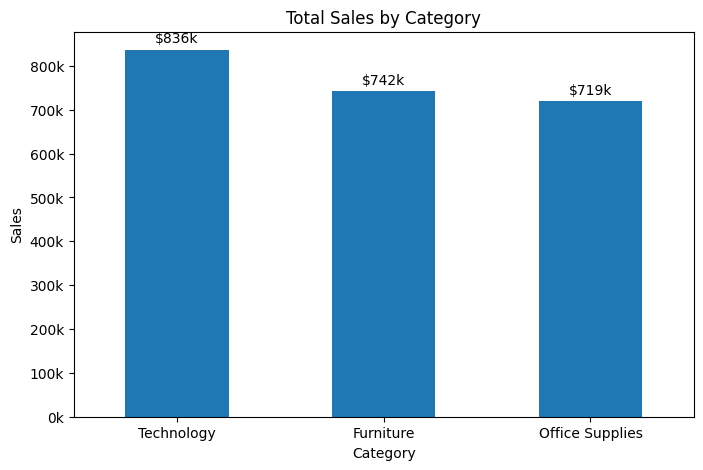

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

sales_by_category = df.groupby("Category", observed=False)["Sales"].sum().sort_values(ascending=False)

plt.figure(figsize=(8,5))
ax = sales_by_category.plot(kind="bar")

plt.title("Total Sales by Category")
plt.xlabel("Category")
plt.ylabel("Sales")
plt.xticks(rotation=0)

# Format y-axis labels to display in thousands (k)
formatter = mticker.FuncFormatter(lambda x, p: f'{int(x/1000)}k')
ax.yaxis.set_major_formatter(formatter)

# Add labels on top of the bars, formatted in thousands
for i, value in enumerate(sales_by_category.values):
    ax.text(i, value + 10000, f'${value/1000:,.0f}k', ha='center', va='bottom') # Adjust y-offset for better visibility, value/1000 and append 'k'

plt.show()

###Business Insight:

#### Technology generated the highest sales, while Office supplies contributed the least.

###Profit by Category

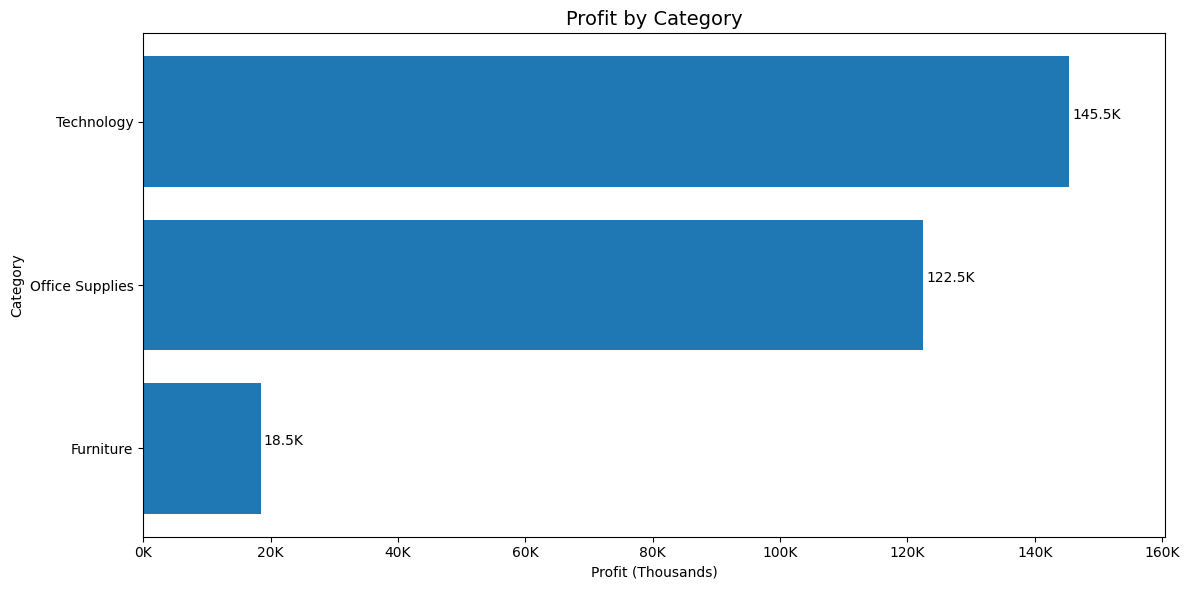

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

# Calculate total profit by category
profit_by_category = (
    df.groupby("Category", observed=False)["Profit"]
      .sum()
      .sort_values(ascending=True)
)

# Create figure with a larger size for better text fitting
plt.figure(figsize=(12, 6))

# Horizontal bar chart
bars = plt.barh(
    profit_by_category.index,
    profit_by_category.values
)

# Title and labels
plt.title("Profit by Category", fontsize=14)
plt.xlabel("Profit (Thousands)")
plt.ylabel("Category")

# Get current axes
ax = plt.gca()

# Format x-axis as K
ax.xaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f"{x/1000:.0f}K")
)

# Add value labels to bars
# Adjust position further to ensure visibility
for bar in bars:
    width = bar.get_width()
    ax.text(
        width + 500,                     # Increased offset for text placement
        bar.get_y() + bar.get_height()/2,
        f"{width/1000:.1f}K",
        va="bottom",
        fontsize=10,
        fontweight="light"
    )

# Adjust x-axis limits to fit the labels properly
# Set the right limit to be beyond the largest bar's value plus its label's estimated width
max_profit_value = profit_by_category.max()
ax.set_xlim(right=max_profit_value + 15000) # Add a buffer to ensure label fits

plt.tight_layout()
plt.show()

##Business Insight:

####Technology leads in profit generation, whereas Furniture contributes the lowest profit.

### Sales by Region

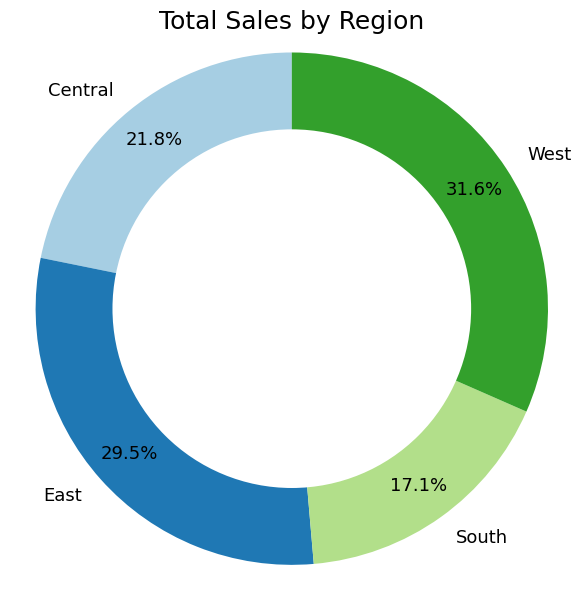

In [ ]:
import matplotlib.pyplot as plt

# Calculate total sales by region
sales_by_region = df.groupby('Region', observed=False)['Sales'].sum()

# Create a figure and a set of subplots with increased figure size
fig, ax = plt.subplots(figsize=(6,6)) # Increased figure size

# Plotting the pie chart
wedges, texts, autotexts = ax.pie(
    sales_by_region,
    labels=sales_by_region.index,
    autopct='%1.1f%%',
    startangle=90,
    pctdistance=0.85, # Distance of percentage labels from center
    colors=plt.cm.Paired.colors # Using a colormap for distinct colors
)

# Draw a white circle in the center to make it a donut chart
centre_circle = plt.Circle((0, 0), 0.70, fc='white')
fig.gca().add_artist(centre_circle)

# Equal aspect ratio ensures that pie is drawn as a circle.
ax.axis('equal')

# Title
plt.title('Total Sales by Region', fontsize=18, fontweight='light') # Slightly increased title fontsize

# Adjust label font sizes for better readability
for text in texts:
    text.set_fontsize(13)
for autotext in autotexts:
    autotext.set_fontsize(13)
    autotext.set_color('black') # Make percentage labels black for contrast

plt.tight_layout() # Ensures everything fits without overlapping
plt.show()

##Business Insight:

The West region generated the highest sales (31.6%), while the South region contributed the lowest sales (17.1%).

##Profit by Region

In [ ]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning, module="plotly.express._core")

import plotly.express as px

# Calculate Profit by Region
profit_by_region = (
    df.groupby("Region", observed=False, as_index=False)["Profit"]
      .sum()
)

# Create a 'Profit_K' column for thousands display
profit_by_region['Profit_K'] = profit_by_region['Profit'] / 1000

# Create Treemap
fig = px.treemap(
    profit_by_region,
    path=["Region"],
    values="Profit_K",
    color="Profit_K",
    color_continuous_scale="Blues",
    title="Profit by Region"
)

fig.update_traces(
    texttemplate="<b>%{label}</b><br>%{value:.1f}K",
    textfont_size=18
)

# Title styling
fig.update_layout(
    title={
        "text": "Profit by Region",
        "x": 0.5,
        "xanchor": "center",
        "font": dict(size=22)
    },
    margin=dict(t=50, l=10, r=10, b=10),
    coloraxis_showscale=False
)

fig.show()

##Business Insight:

The West region generated the highest profit, while the Central region contributed the lowest profit.

##Sales by segment

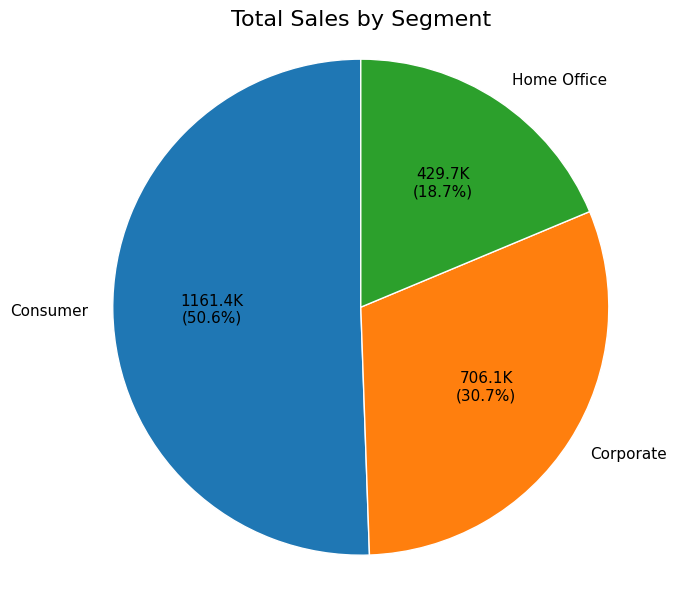

In [ ]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning, module="pandas")

import matplotlib.pyplot as plt

# Calculate Sales by Segment
sales_by_segment = (
    df.groupby("Segment", observed=False)["Sales"]
      .sum()
      .sort_values(ascending=False)
)

# Function to display Sales (K) + Percentage
def autopct_format(values):
    def my_format(pct):
        total = sum(values)
        value = pct * total / 100
        return f"{value/1000:.1f}K\n({pct:.1f}%)"
    return my_format

# Create Figure
plt.figure(figsize=(7,6))

# Pie Chart
plt.pie(
    sales_by_segment,
    labels=sales_by_segment.index,
    autopct=autopct_format(sales_by_segment),
    startangle=90,
    textprops={"fontsize":11},
    wedgeprops={"edgecolor":"white","linewidth":1}
)

# Title
plt.title("Total Sales by Segment", fontsize=16, fontweight="normal")

# Keep circle shape
plt.axis("equal")

plt.tight_layout()
plt.show()

##Business Insight:

The Consumer segment generated the highest sales, while the Home Office segment contributed the lowest sales.

###Discount Vs Profit

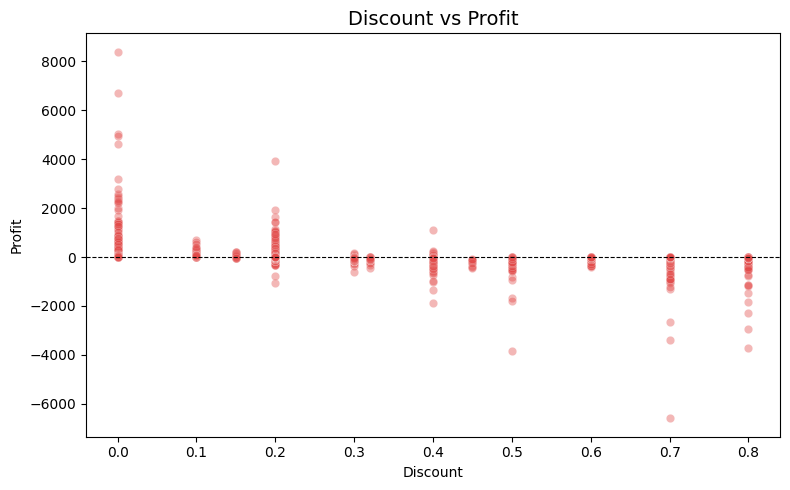

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.scatter(df['Discount'], df['Profit'],
            alpha=0.4, color='#E24B4A', edgecolors='white', linewidth=0.3)
plt.axhline(y=0, color='black', linestyle='--', linewidth=0.8)
plt.title('Discount vs Profit', fontsize=14, fontweight='light')
plt.xlabel('Discount')
plt.ylabel('Profit')
plt.tight_layout()
plt.show()

##Business Insight:

There is a clear inverse relationship between discount and profit; higher discounts generally lead to reduced profits, often resulting in significant losses. Most profitable transactions occur with little to no discount.

###Ship mode and Segment

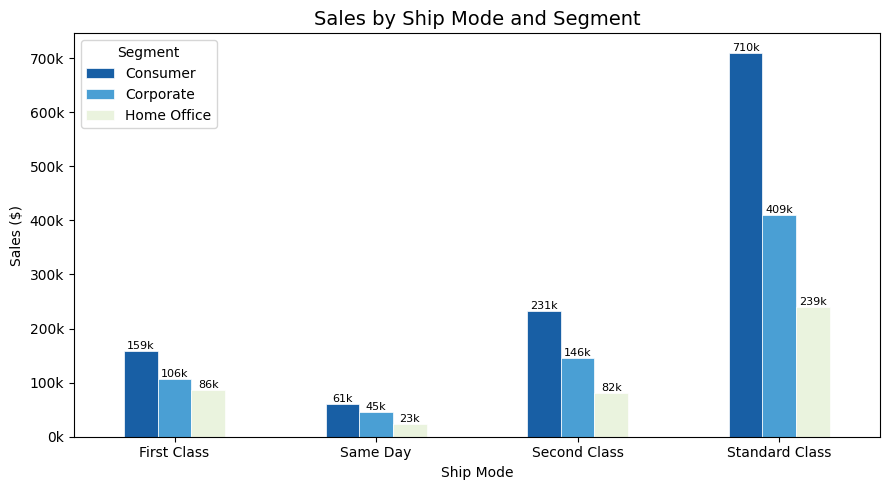

In [ ]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning, module="pandas")

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# Group by Ship Mode and Segment
stacked = df.groupby(['Ship Mode', 'Segment'], observed=False)['Sales'].sum().unstack()

# Plot
ax = stacked.plot(kind='bar', figsize=(9, 5),
             color=['#185FA5', '#4A9FD4', '#EAF3DE'],
             edgecolor='white', linewidth=0.5)

plt.title('Sales by Ship Mode and Segment',
          fontsize=14, fontweight='light')
plt.xlabel('Ship Mode')
plt.ylabel('Sales ($)')
plt.xticks(rotation=0)
plt.legend(title='Segment')

# Format y-axis labels to display in thousands (k)
formatter = mticker.FuncFormatter(lambda x, p: f'{int(x/1000)}k')
ax.yaxis.set_major_formatter(formatter)

# Add labels on top of each bar segment
for container in ax.containers:
    labels = [f'{h.get_height()/1000:.0f}k' if h.get_height() > 0 else '' for h in container]
    ax.bar_label(container, labels=labels, label_type='edge', fontsize=8)

plt.tight_layout()
plt.show()

##Business Insight:

'Standard Class' shipping drives the highest sales, primarily from the 'Consumer' segment, while 'Same Day' is the least used shipping mode.

###Sub-Category Vs Region

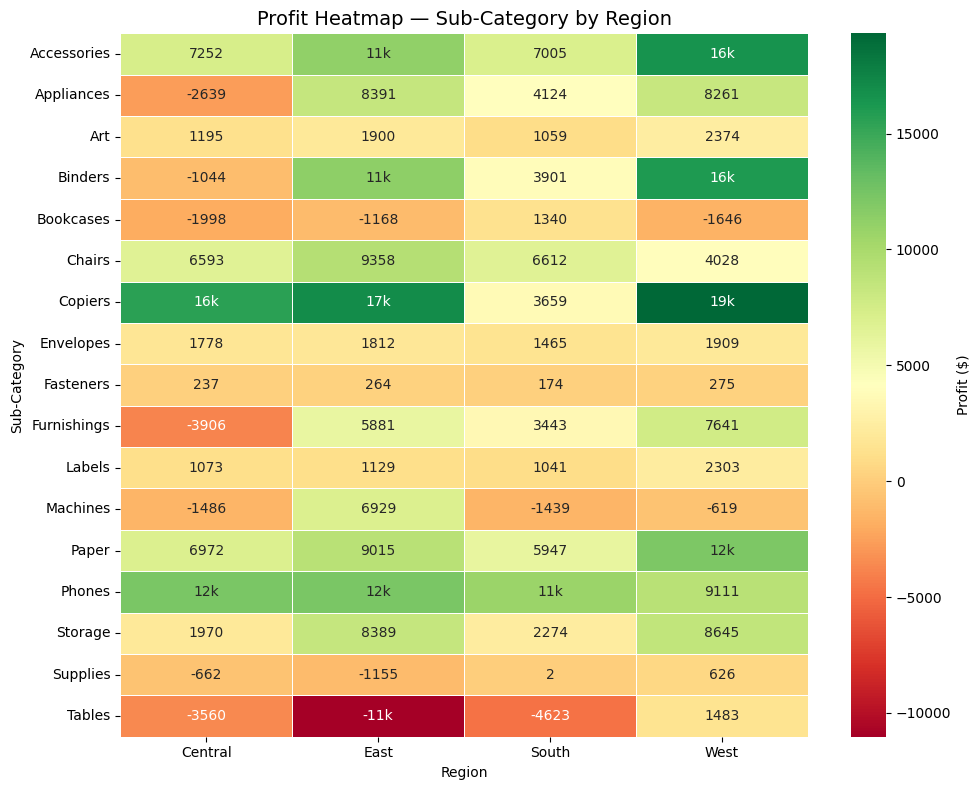

In [ ]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning, module="pandas")

import seaborn as sns
import matplotlib.pyplot as plt

# Group by Sub-Category and Region
heatmap_data = df.groupby(['Sub-Category', 'Region'], observed=False)['Profit'].sum().unstack()

# Custom formatter for annotations
def format_profit(val):
    if abs(val) >= 10000:
        return f'{val/1000:.0f}k'
    return f'{val:.0f}'

# Apply the custom formatter to the heatmap_data to get formatted strings
annot_data = heatmap_data.map(format_profit)

# Plot
plt.figure(figsize=(10, 8))
sns.heatmap(heatmap_data,
            annot=annot_data,     # Use the pre-formatted data for annotations
            fmt='s',              # Indicate that annotations are already strings
            cmap='RdYlGn',        # red=loss, yellow=neutral, green=profit
            linewidths=0.5,
            linecolor='white',
            cbar_kws={'label': 'Profit ($)'})

plt.title('Profit Heatmap — Sub-Category by Region',
          fontsize=14, fontweight='light')
plt.xlabel('Region')
plt.ylabel('Sub-Category')
plt.tight_layout()
plt.show()

##Business Insight:

The West and East regions generally demonstrate strong profitability across sub-categories. However, specific sub-categories like 'Tables' and 'Supplies' show consistent losses, particularly in the Central and East regions, highlighting areas for focused improvement.

###Profit Margin by Region

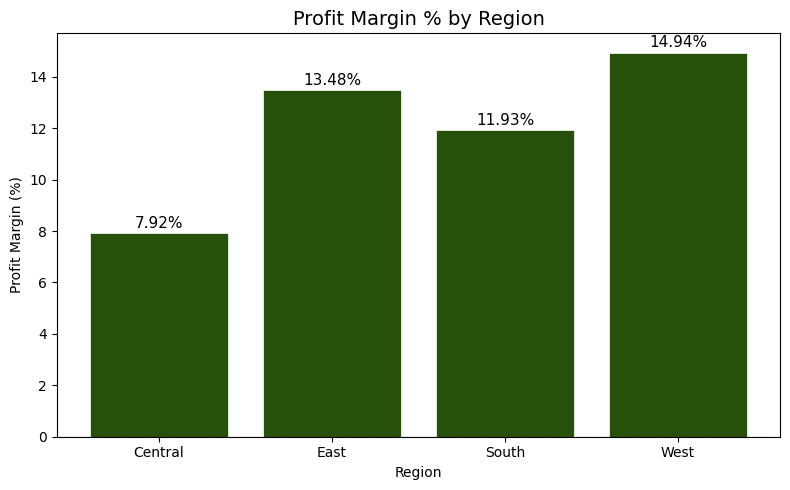

In [ ]:
# Calculate profit margin
region_data = df.groupby('Region', observed=False).agg(
    Total_Sales=('Sales', 'sum'),
    Total_Profit=('Profit', 'sum')
).reset_index()

region_data['Profit_Margin_%'] = (
    region_data['Total_Profit'] / region_data['Total_Sales'] * 100
).round(2)

# Plot
colors = ['#27500A' if x > 0 else '#A32D2D'
          for x in region_data['Profit_Margin_%']]

plt.figure(figsize=(8, 5))
bars = plt.bar(region_data['Region'],
               region_data['Profit_Margin_%'],
               color=colors, edgecolor='white', linewidth=0.5)

# Add % labels on bars
for bar, val in zip(bars, region_data['Profit_Margin_%']):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.2,
             f'{val}%', ha='center', fontsize=11, fontweight='light')

plt.title('Profit Margin % by Region', fontsize=14, fontweight='light')
plt.xlabel('Region')
plt.ylabel('Profit Margin (%)')
plt.axhline(y=0, color='black', linestyle='--', linewidth=0.8)
plt.tight_layout()
plt.show()

## Business Insight:

The West region exhibits the highest profit margin (14.94%), while the Central region has the lowest (7.92%).

###Gemini AI integration

In [20]:
!pip install -q google-genai
from google import genai

from google.colab import userdata

API_KEY = userdata.get("API_KEY")

client = genai.Client(api_key=API_KEY)

business_summary = f"""
Retail Sales Analysis

Key Business Metrics

Total Sales: ${total_sales:,.2f}
Total Profit: ${total_profit:,.2f}
Profit Margin: {profit_margin:.2f}%
Total Orders: {total_orders}
Total Quantity Sold: {total_quantity}

Average Sales per Order: ${average_sales:,.2f}
Average Profit per Order: ${average_profit:,.2f}
Average Discount: {average_discount:.2f}%

Business Coverage

States: {total_states}
Cities: {total_cities}
Regions: {total_regions}
Categories: {total_categories}
Sub-Categories: {total_subcategories}
Shipping Modes: {total_ship_modes}

Business Insights

- Technology generated the highest sales.
- Technology generated the highest profit.
- West region generated the highest sales.
- West region generated the highest profit.
- Consumer segment contributed the highest sales.
"""

prompt = f"""
You are a Senior Business Analyst.

Based on the following retail sales analysis, generate a professional executive report.

Include:

1. Executive Summary
2. Key Findings
3. Business Recommendations
4. Areas of Concern
5. Conclusion

Business Data:

{business_summary}
"""

response = client.models.generate_content(
model="gemini-flash-latest",
contents=prompt
)

print(response.text)

**To:** Executive Leadership Team  
**From:** Senior Business Analyst  
**Date:** October 24, 2023  
**Subject:** Executive Retail Sales Performance Analysis & Strategic Recommendations  

---

### 1. Executive Summary

This report evaluates the overall retail sales performance across **49 states**, covering **9,994 orders** and generating **$2,297,201.07** in total sales revenue. The business achieved a net profit of **$286,397.79**, translating to a net profit margin of **12.47%**. 

Overall financial health is positive, underpinned by strong performance in the **Technology** category, the **West region**, and the **Consumer** customer segment. However, profitability is heavily diluted by an aggressive average discount rate of **15.62%**, leaving an average profit per order of just **$28.66**. Strategic adjustments focused on discount optimization, regional expansion, and product cross-selling are recommended to improve operating margins without sacrificing sales velocity.

---

### 

###Sample Testing of API Key

In [19]:
from google.colab import userdata
from google import genai

API_KEY = userdata.get("API_KEY")

client = genai.Client(api_key=API_KEY)

response = client.models.generate_content(
    model="gemini-flash-latest",
    contents="Hello!"
)

print(response.text)

Hello! How can I help you today?


In [14]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning, module="reportlab")

# ==========================================
# Export AI Report to TXT and PDF
# ==========================================

!pip install -q reportlab

from datetime import datetime
from reportlab.platypus import (
    SimpleDocTemplate,
    Paragraph,
    Spacer
)
from reportlab.lib.styles import getSampleStyleSheet
from reportlab.lib.enums import TA_CENTER
from reportlab.lib.colors import darkblue

# ==========================================
# Save TXT Report
# ==========================================

with open("Retail_Sales_AI_Report.txt", "w", encoding="utf-8") as file:
    file.write(response.text)

print("✅ TXT report saved successfully.")

# ==========================================
# Create PDF Report
# ==========================================

doc = SimpleDocTemplate(
    "Retail_Sales_AI_Report.pdf",

    # PDF Metadata
    title="AI-Powered Retail Sales Analyzer",
    author="Vraj Shah",
    subject="Retail Sales Analysis using Python and Google Gemini AI",
    creator="Python + ReportLab",

    # Page Margins
    rightMargin=40,
    leftMargin=40,
    topMargin=50,
    bottomMargin=40
)

styles = getSampleStyleSheet()

# ---------- Styles ----------

title_style = styles["Title"]
title_style.alignment = TA_CENTER
title_style.textColor = darkblue
title_style.spaceAfter = 18

heading_style = styles["Heading2"]
heading_style.textColor = darkblue
heading_style.spaceBefore = 12
heading_style.spaceAfter = 8

normal_style = styles["BodyText"]
normal_style.spaceAfter = 6

# ---------- Story ----------

story = []

# Report Title
story.append(Paragraph("AI-Powered Retail Sales Analyzer", title_style))
story.append(Paragraph("Executive Business Report", title_style))

today = datetime.today().strftime("%B %d, %Y")
story.append(Paragraph(f"<b>Date:</b> {today}", normal_style))
story.append(Paragraph("<b>Prepared By:</b> Vraj Shah", normal_style))

story.append(Spacer(1, 18))

# ---------- Format Gemini Report ----------

for line in response.text.split("\n"):

    line = line.strip()

    if not line:
        story.append(Spacer(1, 8))
        continue

    # Remove Markdown symbols
    line = (
        line.replace("**", "")
            .replace("### ", "")
            .replace("## ", "")
            .replace("# ", "")
            .replace("#### ", "")
    )

    # Section headings
    headings = [
        "Executive Summary",
        "Key Findings",
        "Business Recommendations",
        "Areas of Concern",
        "Conclusion",
        "Financial & Operational Highlights",
        "Regional Performance",
        "Customer Segment Analysis"
    ]

    if any(line.lower() == h.lower() for h in headings):
        story.append(Paragraph(line, heading_style))
        story.append(Spacer(1, 8))

    # Bullet points
    elif line.startswith("-"):
        story.append(
            Paragraph(
                "&#8226; " + line[1:].strip(),
                normal_style
            )
        )

    elif line.startswith("*"):
        story.append(
            Paragraph(
                "&#8226; " + line[1:].strip(),
                normal_style
            )
        )

    else:
        story.append(Paragraph(line, normal_style))

doc.build(story)

print("✅ PDF report exported successfully.")

✅ TXT report saved successfully.
✅ PDF report exported successfully.
